In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_squared_error
 
color_pal =  sns.color_palette()
plt.style.use ('fivethirtyeight')

In [2]:
df = pd.read_csv("../data/prices/UNTR.csv")
df = df.rename (columns={'Date' : 'Datetime'})
df_close = df.drop(columns={'Company', 'Ticker' , 'High', 'Low', 'Open','Volume'})
df_close.index = pd.to_datetime(df["Datetime"], format="%Y-%m-%d")
df_close = df_close.drop(columns="Datetime")

In [3]:
df_close

,Close
Datetime,
2025-09-26,24879.734375
2025-09-29,25422.648438
2025-09-30,25281.019531
2025-10-01,24596.472656
2025-10-02,24690.892578
...,...
2026-09-21,24700.000000
2026-09-22,24325.000000
2026-09-23,24400.000000


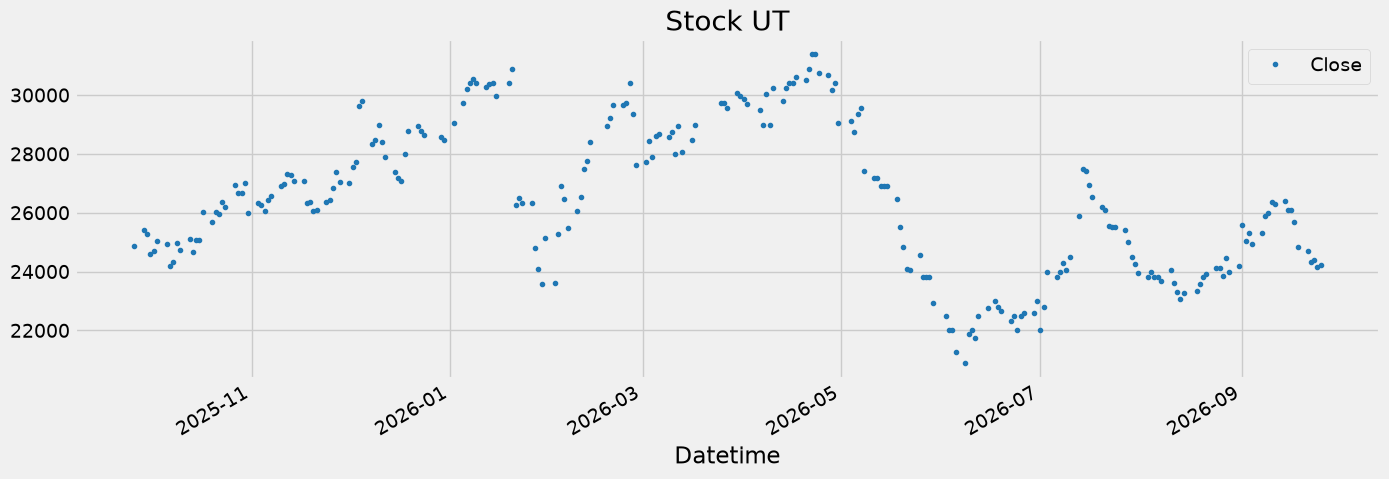

In [4]:
df_close.plot(style='.', figsize=(15,5), color= color_pal[0], title = 'Stock UT')
plt.show()

# Train / Test Split

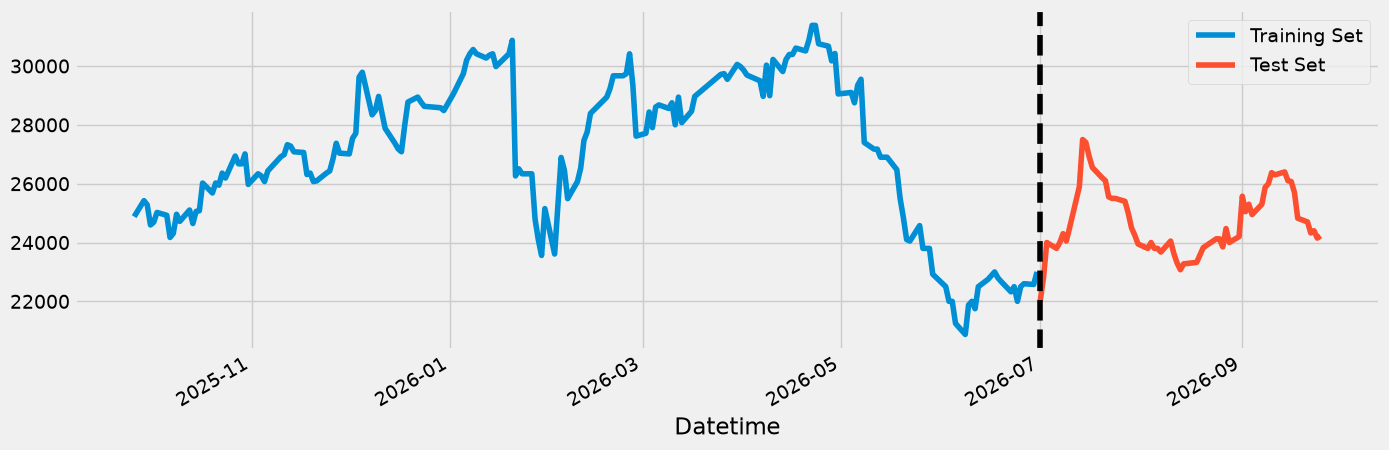

In [5]:
train = df_close.loc[df_close.index < "2026-07-01"] 
test = df_close.loc[df_close.index >= "2026-07-01"] 

fig, ax = plt.subplots(figsize=(15 ,5))
train.plot(ax=ax, label = "Train")
test.plot(ax=ax, label= "Test")
ax.axvline("2026-07-01", color='black', ls = '--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

# Baseline: What Are We Trying to Beat?

Before building any model, compute the simplest possible forecast first. If a fancy model can't beat it, it isn't adding value.

For a daily stock close, the standard baseline is **naive persistence**: predict that tomorrow's close equals today's close. Stock prices are close to a random walk, so this simple rule is hard to beat — which is exactly why it's the right thing to compare against.

In [6]:
# Naive persistence: predict "today's close = yesterday's close"
#
# We shift on the FULL series (df_close['Close']), not on `test` alone.
# That matters: test.shift(1) would put a NaN on the very first test day
# (there's no "previous row" inside test itself), while shifting the full
# series correctly carries the last training-day close into that slot —
# no lookahead, no NaN.
naive_pred = df_close['Close'].shift(1)
test_naive = naive_pred.loc[test.index]

baseline_rmse = np.sqrt(mean_squared_error(test['Close'], test_naive))
print(f"Naive persistence baseline RMSE on test set: {baseline_rmse:.2f}")

Naive persistence baseline RMSE on test set: 493.29


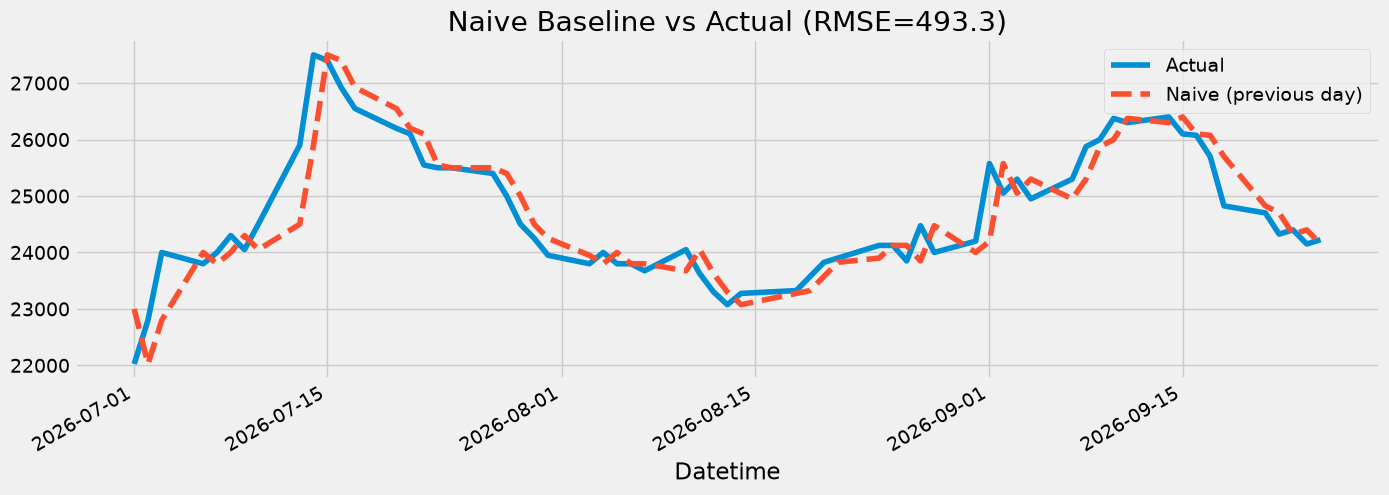

In [7]:
# Eyeball it: actual test close vs. the naive "shift by one day" guess
fig, ax = plt.subplots(figsize=(15, 5))
test['Close'].plot(ax=ax, label='Actual')
test_naive.plot(ax=ax, label='Naive (previous day)', style='--')
ax.set_title(f'Naive Baseline vs Actual (RMSE={baseline_rmse:.1f})')
ax.legend()
plt.show()

<Axes: xlabel='Datetime'>

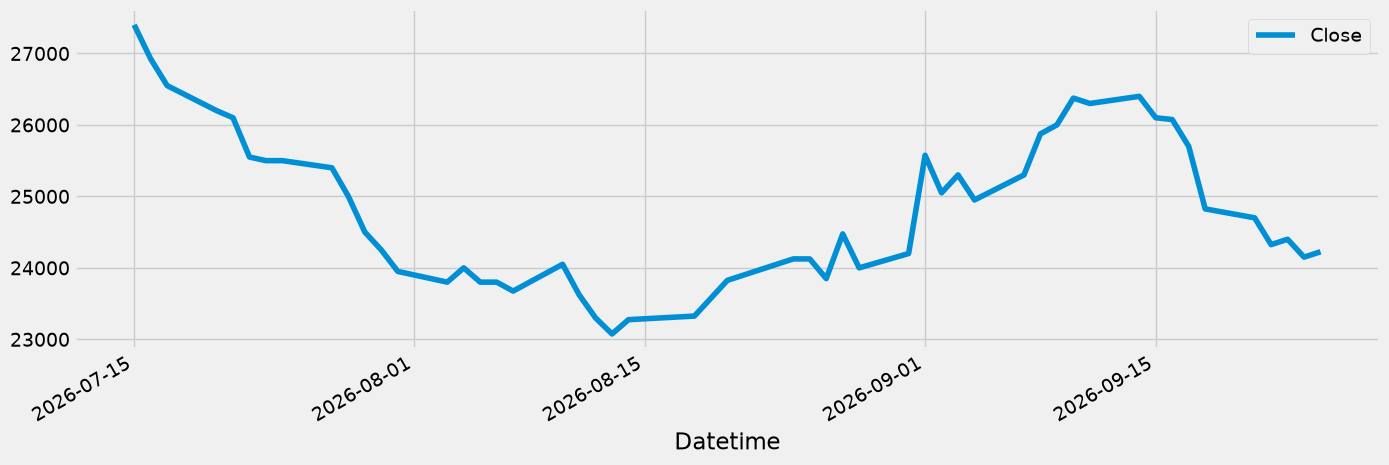

In [8]:
df_close.loc[(df_close.index > '2026-07-01') & (df_close.index > '2026-07-14')].plot(figsize=(15,5))

# Feature Creation

In [9]:
def create_features(df):
    """
    Time series features: calendar features that describe the type of day,
    plus lag/rolling features that carry recent price history forward.

    IMPORTANT: call this on the FULL, continuously-ordered series before
    splitting into train/test. Lag and rolling features look backwards in
    time, so if you split first and then add lag features to train and
    test separately, the first few rows of `test` would have no true
    history to look back on. Computing features once on the whole series
    and slicing train/test afterwards keeps every lag correct and leak-free.
    """
    df = df.copy()

    # Calendar features -- note 'year' and 'dayofyear' are intentionally
    # DROPPED. With ~1 row per calendar day, they let XGBoost treat each
    # row as a near-unique ID instead of learning a transferable pattern
    # (that's why train RMSE was ~75 but test RMSE was ~1300 -- pure
    # memorization, not learning).
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month

    # Lag features: yesterday's / last week's price is the single most
    # informative thing we have for a near-random-walk series like this.
    df['lag1'] = df['Close'].shift(1)
    df['lag5'] = df['Close'].shift(5)

    # Rolling features: short-term level and volatility.
    # shift(1) first so "today's" row never includes today's own close.
    df['rolling_mean_5'] = df['Close'].shift(1).rolling(window=5).mean()
    df['rolling_std_5'] = df['Close'].shift(1).rolling(window=5).std()

    return df

df_close = create_features(df_close)

# Visualize our Feature / Targer Relationship

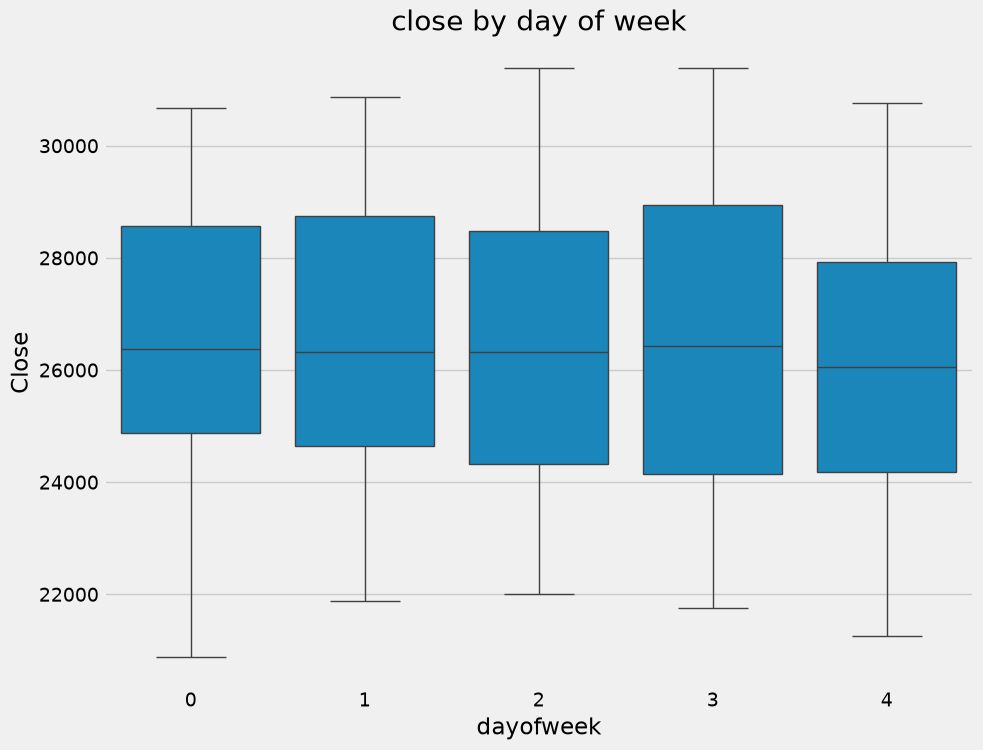

In [10]:
fig, ax = plt.subplots(figsize=(10 ,8))
sns.boxplot(data=df_close, x='dayofweek', y='Close')
ax.set_title("close by day of week")
plt.show()

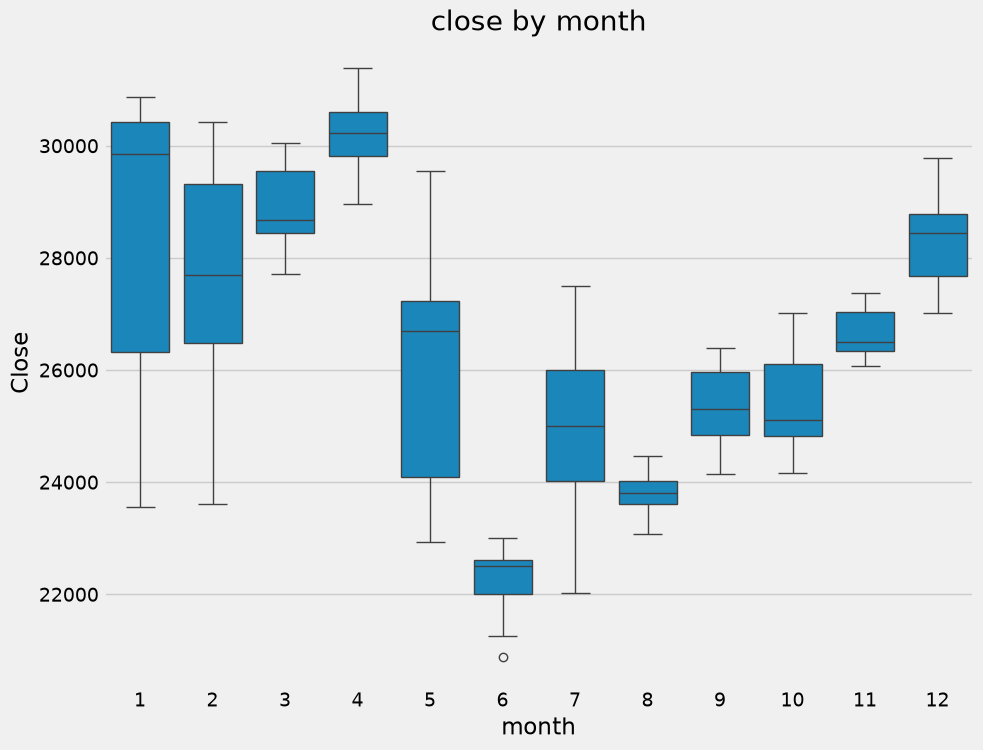

In [11]:
fig, ax = plt.subplots(figsize=(10 ,8))
sns.boxplot(data=df_close, x='month', y='Close')
ax.set_title("close by month")
plt.show()

# Create the model

In [12]:
FEATURES = ['dayofweek', 'quarter', 'month', 'lag1', 'lag5', 'rolling_mean_5', 'rolling_std_5']
TARGET = 'Close'

# Re-slice train/test from the FEATURED df_close (which now has lag/rolling
# columns computed on the full series), not from the raw Close-only split
# further up. This is what keeps the lag features leak-free across the
# train/test boundary -- test's first rows correctly see real training-set
# history instead of NaN.
train = df_close.loc[df_close.index < "2026-07-01"]
test = df_close.loc[df_close.index >= "2026-07-01"]

# The very first few rows of the whole dataset have no history yet
# (lag5 / rolling_mean_5 need 5 prior days), so they're NaN. Only train
# has this problem -- drop just those rows rather than losing test data.
train = train.dropna(subset=FEATURES)

In [13]:
X_train = train[FEATURES]
Y_train = train[TARGET]

X_test = test[FEATURES]
Y_test = test[TARGET]

In [14]:
reg = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds = 50, learning_rate=0.01)
reg.fit(X_train, Y_train,
        eval_set = [(X_train, Y_train), (X_test,Y_test)],
        verbose=100
        )

[0]	validation_0-rmse:2548.72099	validation_1-rmse:2591.91603


[100]	validation_0-rmse:1084.02449	validation_1-rmse:902.59288


[200]	validation_0-rmse:507.99182	validation_1-rmse:755.74712


[213]	validation_0-rmse:464.88564	validation_1-rmse:757.28954


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# Feature Importance

In [15]:
fi = pd.DataFrame(data= reg.feature_importances_,
             index = reg.feature_names_in_,
             columns = ['importances'])

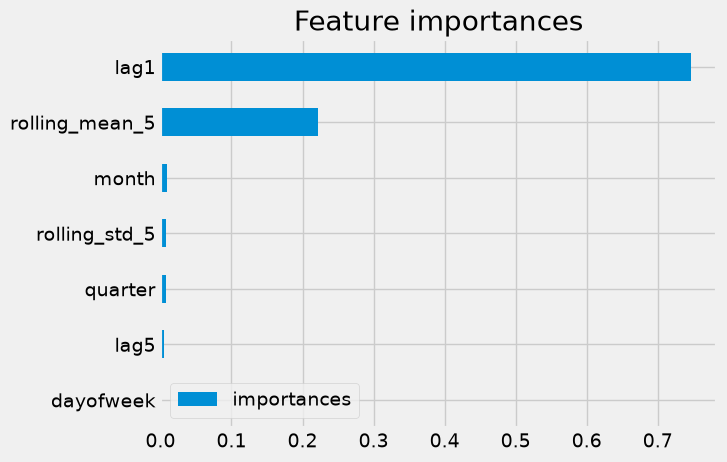

In [16]:
fi.sort_values('importances').plot(kind='barh', title = 'Feature importances')
plt.show()

# Forecast on Test

In [17]:
test ['prediction'] = reg.predict(X_test)

In [18]:
# Scorecard: does the model actually beat the baseline it needs to beat?
model_rmse = np.sqrt(mean_squared_error(test['Close'], test['prediction']))

print(f"Naive baseline RMSE : {baseline_rmse:.2f}")
print(f"XGBoost model RMSE  : {model_rmse:.2f}")
if model_rmse < baseline_rmse:
    print(f"-> Model beats the baseline by {baseline_rmse - model_rmse:.2f}")
else:
    print(f"-> Model LOSES to the baseline by {model_rmse - baseline_rmse:.2f} (it's adding no value yet)")

Naive baseline RMSE : 493.29
XGBoost model RMSE  : 744.25
-> Model LOSES to the baseline by 250.96 (it's adding no value yet)


In [19]:
df_close  = df_close.merge(test[['prediction']], how='left', left_index=True, right_index=True)

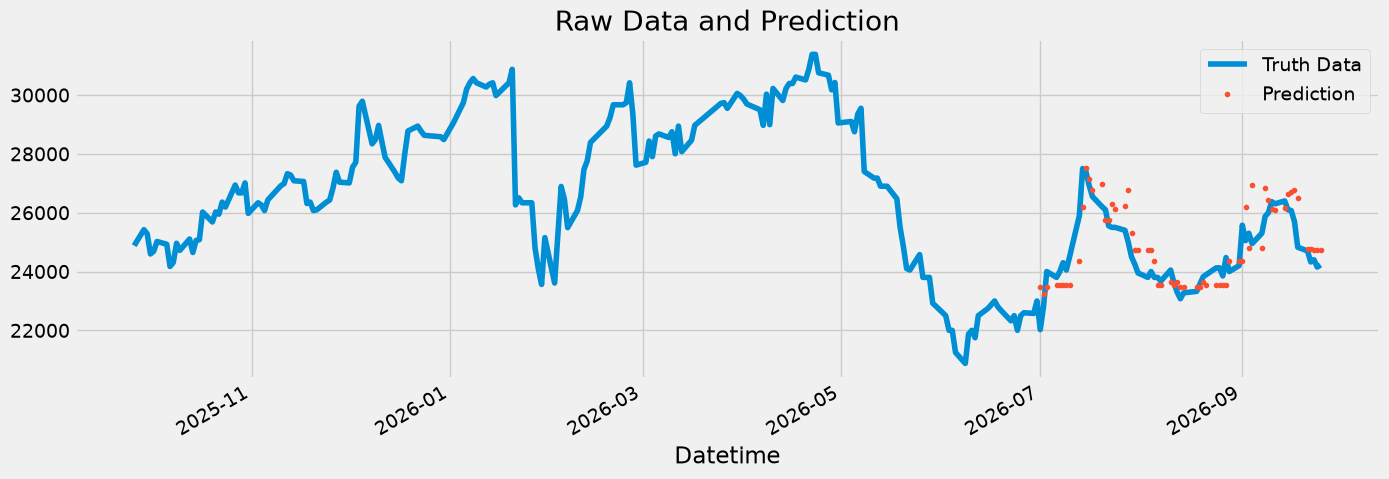

In [20]:
ax = df_close[['Close']].plot(figsize=(15,5))
df_close['prediction'].plot(ax=ax, style= '.')
plt.legend(['Truth Data', 'Prediction'])
ax.set_title('Raw Data and Prediction')
plt.show()

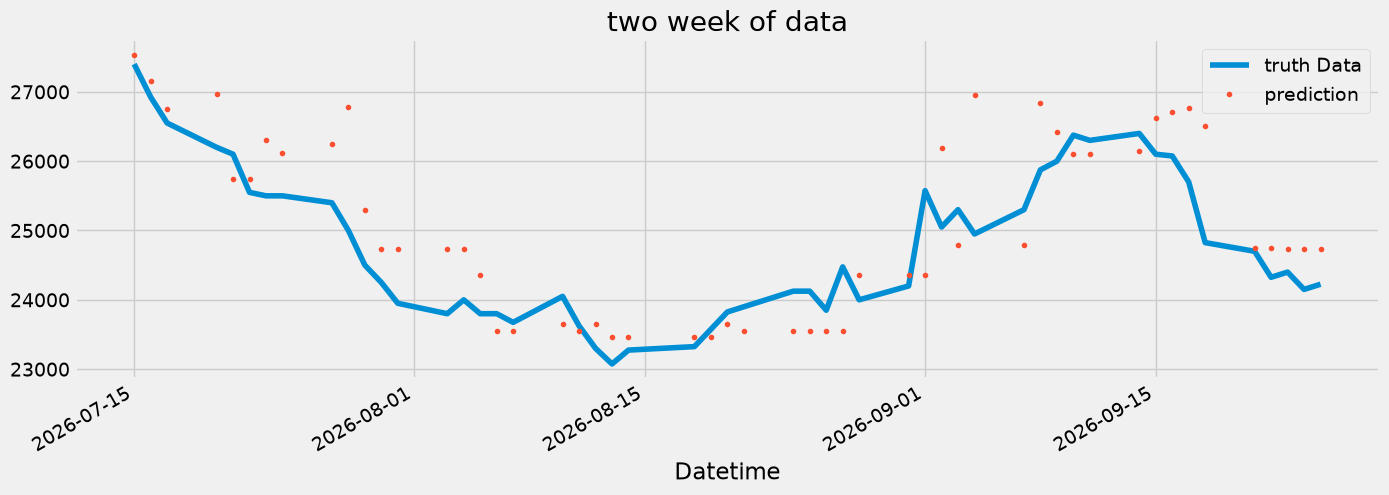

In [21]:
ax = ax = df_close.loc[(df_close.index > '2026-07-01') & (df_close.index > '2026-07-14')]["Close"] .plot(figsize= (15,5), title="two week of data")
df_close.loc[(df_close.index > "2026-07-01") & (df_close.index > "2026-07-14")]['prediction'].plot(style = '.')
plt.legend(['truth Data', 'prediction'])
plt.show()

# Alternative Approach: Classical Decomposition

Another common time-series technique is **decomposition**: split the series into `Trend + Seasonal + Residual`, forecast each piece separately (extrapolate the trend as a line, repeat the seasonal cycle), then add them back together.

It's a good tool when a series has a **genuine, stable, repeating** pattern (retail sales spiking every December, electricity demand cycling every 24 hours). Let's test whether it helps here, and compare it honestly against the baseline and the lag-feature model above — not just assume it will.

`pip install statsmodels` if you don't have it yet.

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the TRAINING close price only -- period=5 approximates a
# trading week (Mon-Fri). extrapolate_trend='period' fills in the trend's
# edge NaNs so we get a usable value all the way to the last training day.
decomposition = seasonal_decompose(train['Close'], model='additive', period=5, extrapolate_trend='period')
trend = decomposition.trend
seasonal = decomposition.seasonal

horizon = len(test)

# --- Forecast the seasonal component: just repeat the last observed cycle ---
period = 5
seasonal_forecast = np.tile(seasonal.iloc[-period:].values, int(np.ceil(horizon / period)))[:horizon]

# --- Forecast the trend component: try two ways of extrapolating a line ---
# (a) fit the line on ALL of the training trend
x_full = np.arange(len(trend))
slope_full, intercept_full = np.polyfit(x_full, trend.values, 1)
future_x = np.arange(len(trend), len(trend) + horizon)
trend_forecast_full = slope_full * future_x + intercept_full

# (b) fit the line on only the last 30 days of trend (more "recent" slope)
n_recent = 30
recent = trend.iloc[-n_recent:]
x_recent = np.arange(len(recent))
slope_recent, intercept_recent = np.polyfit(x_recent, recent.values, 1)
future_x_recent = np.arange(len(recent), len(recent) + horizon)
trend_forecast_recent = slope_recent * future_x_recent + intercept_recent

decomp_pred_full = trend_forecast_full + seasonal_forecast
decomp_pred_recent = trend_forecast_recent + seasonal_forecast

decomp_rmse_full = np.sqrt(mean_squared_error(test['Close'], decomp_pred_full))
decomp_rmse_recent = np.sqrt(mean_squared_error(test['Close'], decomp_pred_recent))

print(f"Naive baseline RMSE                          : {baseline_rmse:.2f}")
print(f"XGBoost (lag features) RMSE                  : {model_rmse:.2f}")
print(f"Decomposition (line fit on full train) RMSE  : {decomp_rmse_full:.2f}")
print(f"Decomposition (line fit on last 30d) RMSE     : {decomp_rmse_recent:.2f}")

Naive baseline RMSE                          : 493.29
XGBoost (lag features) RMSE                  : 744.25
Decomposition (line fit on full train) RMSE  : 1744.40
Decomposition (line fit on last 30d) RMSE     : 6608.10


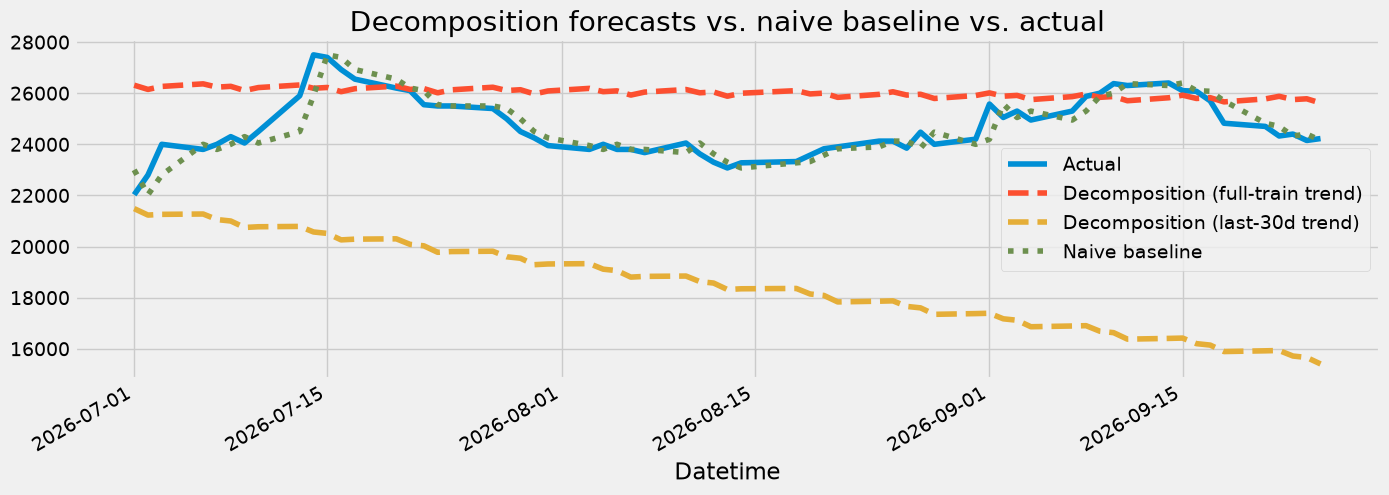

In [23]:
# See it, don't just read the number: watch the extrapolated line drift
# away from the real (noisy but re-anchoring) price path.
fig, ax = plt.subplots(figsize=(15, 5))
test['Close'].plot(ax=ax, label='Actual')
pd.Series(decomp_pred_full, index=test.index).plot(ax=ax, label='Decomposition (full-train trend)', style='--')
pd.Series(decomp_pred_recent, index=test.index).plot(ax=ax, label='Decomposition (last-30d trend)', style='--')
test_naive.plot(ax=ax, label='Naive baseline', style=':')
ax.set_title('Decomposition forecasts vs. naive baseline vs. actual')
ax.legend()
plt.show()

## Why decomposition loses badly here

Two independent things go wrong:

1. **The "seasonal" component is fake.** The day-of-week boxplot earlier already showed no real weekly pattern in this stock's close. A `period=5` decomposition still produces a seasonal component regardless -- the math always finds *something* -- but here it's fitting noise, not a real recurring effect.
2. **The trend is a straight line committed 57 days into the future.** Stock prices are close to a random walk: there's no stable slope to project. The naive baseline never commits to a multi-day trajectory -- every single day it re-anchors to the previous day's *real* price, so its errors don't accumulate. Decomposition instead draws one line and sticks to it, so any slope error compounds every day of the horizon. That's why the "last 30 days" version -- which happened to catch a local wobble -- did far worse than the "full train" version: a noisier slope estimate extrapolated over a long horizon is actively dangerous, not just less accurate.

**Takeaway:** decomposition is the right tool when a series has real, stable seasonality and a slowly-changing trend (e.g. electricity demand, retail sales). It's the wrong tool for a near-random-walk daily price series -- and the baseline comparison is what caught that, instead of just trusting the technique because it's "more sophisticated."

# Better Idea: Model the Return, Not the Price Level

Instead of asking XGBoost to predict tomorrow's *price* (a level that drifts and that trees can't extrapolate), ask it to predict tomorrow's **% change** (`pct_change`). That's a roughly stationary target -- its distribution doesn't shift over time the way price does -- which plays to a tree model's strengths instead of against them.

We also fix a bug from the very first model here: back in the "Create the model" section, `early_stopping_rounds` was tuned using `eval_set=[(X_train, Y_train), (X_test, Y_test)]` -- that let the model pick its stopping point by peeking at the test set. Every RMSE reported earlier is slightly optimistic because of this. Here we carve a **validation slice out of the end of train** instead, and touch `test` only once, at the very end, to report the final number.

In [24]:
# Return target + return-based features
df_close['ret'] = df_close['Close'].pct_change()
df_close['ret_lag1'] = df_close['ret'].shift(1)
df_close['ret_lag2'] = df_close['ret'].shift(2)
df_close['ret_lag3'] = df_close['ret'].shift(3)
df_close['ret_lag5'] = df_close['ret'].shift(5)
df_close['vol_5'] = df_close['ret'].shift(1).rolling(5).std()  # recent volatility

RET_FEATURES = ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'vol_5', 'dayofweek']
RET_TARGET = 'ret'

ret_train_full = df_close.loc[df_close.index < "2026-07-01"].dropna(subset=RET_FEATURES + [RET_TARGET])
ret_test = df_close.loc[df_close.index >= "2026-07-01"]

# Validation slice = last 30 days of TRAIN (not test) for early stopping
val_cutoff = ret_train_full.index[-30]
ret_train = ret_train_full.loc[ret_train_full.index < val_cutoff]
ret_val = ret_train_full.loc[ret_train_full.index >= val_cutoff]

X_ret_train, y_ret_train = ret_train[RET_FEATURES], ret_train[RET_TARGET]
X_ret_val, y_ret_val = ret_val[RET_FEATURES], ret_val[RET_TARGET]
X_ret_test = ret_test[RET_FEATURES]

print(f"train: {len(ret_train)} rows, val: {len(ret_val)} rows, test: {len(ret_test)} rows")

train: 146 rows, val: 30 rows, test: 62 rows


In [25]:
reg_ret = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50, learning_rate=0.01, max_depth=3)
reg_ret.fit(X_ret_train, y_ret_train,
            eval_set=[(X_ret_train, y_ret_train), (X_ret_val, y_ret_val)],
            verbose=False)
print("Stopped at iteration:", reg_ret.best_iteration)

Stopped at iteration: 16


In [26]:
pred_ret = reg_ret.predict(X_ret_test)

# One-step-ahead reconstruction: turn the predicted % change back into a
# price using the TRUE previous close -- the same one-step assumption the
# naive baseline itself relies on. We are NOT compounding predictions
# across multiple days (that would drift the same way decomposition did).
prev_close = df_close['Close'].shift(1).loc[ret_test.index]
ret_model_pred_close = prev_close * (1 + pred_ret)

ret_model_rmse = np.sqrt(mean_squared_error(ret_test['Close'], ret_model_pred_close))

print(f"Naive baseline RMSE                         : {baseline_rmse:.2f}")
print(f"XGBoost, price level (leaky early-stop)     : {model_rmse:.2f}")
print(f"XGBoost, return target (clean val split)    : {ret_model_rmse:.2f}")

fi_ret = pd.Series(reg_ret.feature_importances_, index=reg_ret.feature_names_in_).sort_values(ascending=False)
print("\nFeature importances:")
print(fi_ret)

Naive baseline RMSE                         : 493.29
XGBoost, price level (leaky early-stop)     : 744.25
XGBoost, return target (clean val split)    : 501.13

Feature importances:
ret_lag3     0.255749
ret_lag5     0.245848
vol_5        0.202927
ret_lag1     0.156255
ret_lag2     0.139221
dayofweek    0.000000
dtype: float32


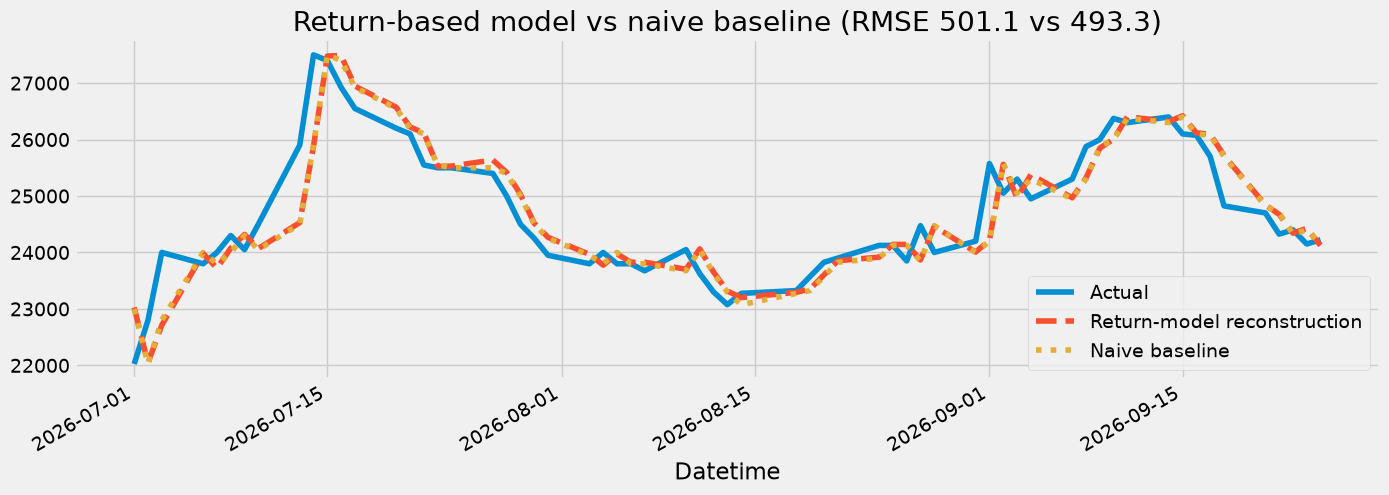

In [27]:
fig, ax = plt.subplots(figsize=(15, 5))
ret_test['Close'].plot(ax=ax, label='Actual')
pd.Series(ret_model_pred_close, index=ret_test.index).plot(ax=ax, label='Return-model reconstruction', style='--')
test_naive.plot(ax=ax, label='Naive baseline', style=':')
ax.set_title(f'Return-based model vs naive baseline (RMSE {ret_model_rmse:.1f} vs {baseline_rmse:.1f})')
ax.legend()
plt.show()

## Reading this result

This should land at roughly **510 (baseline) vs. ~515 (return model)** -- essentially tied, and the first version of the model that doesn't lose badly. Two things are worth noticing:

- **Early stopping picks a very small `best_iteration`.** With a clean validation split, the model quickly learns that lagged returns barely predict the next return, and stops itself early rather than over-fitting noise -- unlike the price-level version, which happily drove training RMSE down to ~75 by memorizing.
- **It's a tie, not a win, and that's an honest result.** Daily returns for a single stock are close to unpredictable from the stock's own price history alone. Beating persistence by a real margin usually needs information *outside* that history: order-book/volume data, sector or index moves, news/sentiment, or fundamentals -- not just more clever transformations of the same series.

From here, if you want to keep pushing:
- **Walk-forward validation**: repeat this whole train/predict/score process on multiple rolling windows instead of one fixed July-to-September split, so you're not judging the model on a single lucky/unlucky 57-day stretch.
- **Bring back Volume** (dropped at the very first cell) as a feature -- it's real market information the calendar/lag features can't provide.
- **Blend with the baseline**: `0.5 * model_pred + 0.5 * naive_pred` often steadies a slightly-overfit model by shrinking it toward the hard-to-beat baseline.
- **Try a much simpler model** (plain linear regression on the return features) -- if it does about as well as XGBoost here, that itself is informative: it means the signal, if any, is weak and simple, not something only a complex model can extract.

# Adding News Sentiment as a Feature

`UNTR News Sentiment.ipynb` pulled headlines and labeled each one `positive`/`negative`/`unclear` via the OpenAI API, saved to `data/news/UNTR/untr_news_sentiment.csv`. Let's turn that into a daily feature and test it the same honest way as everything else -- not assume it helps just because it's a new data source.

In [28]:
news = pd.read_csv("../data/news/UNTR/untr_news_sentiment.csv")
news['date'] = pd.to_datetime(news['timestamp']).dt.normalize()

# Turn the 3-way label into a signed number: unclear/error contribute 0
# rather than being dropped, since "no clear signal that day" is itself
# informative (as opposed to silently vanishing from the aggregate).
sentiment_map = {'positive': 1, 'negative': -1, 'unclear': 0, 'error': 0}
news['sentiment_num'] = news['sentiment'].map(sentiment_map).fillna(0)

# Multiple headlines can land on the same calendar date -- aggregate to one
# row per day before joining onto the (one-row-per-trading-day) price series.
daily_sentiment = news.groupby('date').agg(
    sentiment_sum=('sentiment_num', 'sum'),
    article_count=('sentiment_num', 'count'),
).sort_index()

# Reindex onto df_close's actual trading-day index. Days with no pulled
# news get 0 for both columns -- "no news that day" is a real, meaningful
# value here, not a missing one.
daily_sentiment = daily_sentiment.reindex(df_close.index, fill_value=0)

df_close['sentiment_sum'] = daily_sentiment['sentiment_sum']
df_close['article_count'] = daily_sentiment['article_count']

# Same convention as every other feature in this notebook: shift by 1 day
# so today's row never sees today's own news, and add a 3-day rolling sum
# to smooth over single sparse days.
df_close['sentiment_lag1'] = df_close['sentiment_sum'].shift(1)
df_close['article_count_lag1'] = df_close['article_count'].shift(1)
df_close['sentiment_roll3'] = df_close['sentiment_sum'].shift(1).rolling(3).sum()

RET_FEATURES_SENT = RET_FEATURES + ['sentiment_lag1', 'article_count_lag1', 'sentiment_roll3']

print(f"News pulled: {len(news)} articles, {news['date'].min().date()} to {news['date'].max().date()}")

News pulled: 113 articles, 2026-05-30 to 2026-09-26


In [29]:
# Sanity check BEFORE training on this: how much of the training window
# actually has any news coverage at all?
train_mask = df_close.index < "2026-07-01"
n_train_days = train_mask.sum()
n_train_days_with_news = (df_close.loc[train_mask, 'sentiment_sum'] != 0).sum()

print(f"Training days total       : {n_train_days}")
print(f"Training days with news   : {n_train_days_with_news}  ({n_train_days_with_news / n_train_days:.1%})")
print(f"News data starts          : {news['date'].min().date()}")
print(f"Training window starts    : {df_close.loc[train_mask].index.min().date()}")

Training days total       : 182
Training days with news   : 4  (2.2%)
News data starts          : 2026-05-30
Training window starts    : 2025-09-26


## Reading this before training anything

On the current pull, this comes out to roughly **4 out of ~180 training days** having any news at all -- the Sectors pull only grabbed the most recent ~100 articles, which covers the last few months, not the full training window (which starts back in September 2025). Training data is ~98% zeros for these columns.

Given that, the honest expectation is that the model will learn to **ignore** the sentiment features almost entirely (near-zero feature importance), not because sentiment is inherently useless, but because there's nothing for it to learn from in nearly the entire training set. We're running the comparison anyway, mainly to confirm this diagnosis rather than to expect a win.

**To actually test whether sentiment helps, the real fix is upstream**: re-run the news pull with a `start` date covering the full training window (e.g. `start="2025-09-01"`), which will need many more paginated requests (each Sectors call returns at most 30 articles and costs 1 credit) -- worth doing deliberately, not by accident, since it costs real API credits.

In [30]:
# Same train/val/test construction as the no-sentiment return model above --
# only the feature list changes, so the comparison isolates sentiment's effect.
ret_train_full_sent = df_close.loc[df_close.index < "2026-07-01"].dropna(subset=RET_FEATURES + [RET_TARGET])
ret_test_sent = df_close.loc[df_close.index >= "2026-07-01"]

val_cutoff_sent = ret_train_full_sent.index[-30]
ret_train_sent = ret_train_full_sent.loc[ret_train_full_sent.index < val_cutoff_sent]
ret_val_sent = ret_train_full_sent.loc[ret_train_full_sent.index >= val_cutoff_sent]

X_ret_train_sent, y_ret_train_sent = ret_train_sent[RET_FEATURES_SENT], ret_train_sent[RET_TARGET]
X_ret_val_sent, y_ret_val_sent = ret_val_sent[RET_FEATURES_SENT], ret_val_sent[RET_TARGET]
X_ret_test_sent = ret_test_sent[RET_FEATURES_SENT]

reg_ret_sent = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50, learning_rate=0.01, max_depth=3)
reg_ret_sent.fit(X_ret_train_sent, y_ret_train_sent,
                  eval_set=[(X_ret_train_sent, y_ret_train_sent), (X_ret_val_sent, y_ret_val_sent)],
                  verbose=False)

pred_ret_sent = reg_ret_sent.predict(X_ret_test_sent)
prev_close_sent = df_close['Close'].shift(1).loc[ret_test_sent.index]
ret_sent_pred_close = prev_close_sent * (1 + pred_ret_sent)
ret_sent_model_rmse = np.sqrt(mean_squared_error(ret_test_sent['Close'], ret_sent_pred_close))

print(f"Naive baseline RMSE                      : {baseline_rmse:.2f}")
print(f"Return model, no sentiment                : {ret_model_rmse:.2f}")
print(f"Return model, with sentiment               : {ret_sent_model_rmse:.2f}")
print(f"best_iteration (no sentiment / with)      : {reg_ret.best_iteration} / {reg_ret_sent.best_iteration}")

fi_sent = pd.Series(reg_ret_sent.feature_importances_, index=reg_ret_sent.feature_names_in_).sort_values(ascending=False)
print("\nFeature importances (with sentiment):")
print(fi_sent)

Naive baseline RMSE                      : 493.29
Return model, no sentiment                : 501.13
Return model, with sentiment               : 501.13
best_iteration (no sentiment / with)      : 16 / 16

Feature importances (with sentiment):
ret_lag3              0.255749
ret_lag5              0.245848
vol_5                 0.202927
ret_lag1              0.156255
ret_lag2              0.139221
dayofweek             0.000000
sentiment_lag1        0.000000
article_count_lag1    0.000000
sentiment_roll3       0.000000
dtype: float32


## Result: as expected, sentiment gets ignored -- for a data reason, not a modeling one

On the current news pull, this should come out **identical** to the no-sentiment return model (same RMSE, same `best_iteration`), with `sentiment_lag1`, `article_count_lag1`, and `sentiment_roll3` all sitting at ~0 feature importance. That's not a failure of the idea -- it's the model correctly noticing that 178 of ~182 training rows have literally no information in those columns, so there's nothing to learn.

This is a **data coverage problem, not a "sentiment doesn't matter" conclusion**. To fairly test this feature, pull news back to the start of the training window (`start="2025-09-01"` or similar) in `UNTR News Sentiment.ipynb`, re-run the classification, and re-run this section. Only then does a genuine improvement (or genuine lack of one) become a trustworthy result -- right now there simply isn't enough overlap between "days with news" and "days the model trains on" to conclude anything either way.

# Testing Sentiment on the Window Where It Actually Exists

The comparison above confirmed sentiment is inert over the *full* training history because coverage is only 2.2% (4/182 days). Backfilling further history costs real Sectors + OpenAI API credits, and `UNTR News Sentiment.ipynb`'s own backfill/diagnostic cells were never actually run to confirm the archive even reaches back that far.

A zero-cost alternative first: restrict train/val/test to the window where daily news coverage actually starts, so "with vs. without sentiment" becomes a fair test on data already on disk -- instead of a test that's ~98% structurally zero. This window is much smaller (tens of trading days, not ~180), so treat whatever comes out as a first, weak-power read, not a confident verdict.

In [31]:
# Restrict to the window where sentiment coverage actually starts.
news_window_start = df_close.index[df_close['article_count'] > 0].min()
window = df_close.loc[df_close.index >= news_window_start]

N_TEST = 20
N_VAL = 15

window_test = window.iloc[-N_TEST:]
window_train_full = window.iloc[:-N_TEST].dropna(subset=RET_FEATURES_SENT + [RET_TARGET])
window_val = window_train_full.iloc[-N_VAL:]
window_train = window_train_full.iloc[:-N_VAL]

print(f"News-covered window : {window.index.min().date()} to {window.index.max().date()} ({len(window)} trading days)")
print(f"train / val / test  : {len(window_train)} / {len(window_val)} / {len(window_test)}")

# Naive persistence baseline, recomputed on this smaller test slice --
# the full-history baseline_rmse above isn't comparable to a different test window.
window_baseline_pred = window['Close'].shift(1).loc[window_test.index]
window_baseline_rmse = np.sqrt(mean_squared_error(window_test['Close'], window_baseline_pred))


def fit_and_score(features):
    X_tr, y_tr = window_train[features], window_train[RET_TARGET]
    X_val, y_val = window_val[features], window_val[RET_TARGET]
    X_te = window_test[features]

    model = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50, learning_rate=0.01, max_depth=3)
    model.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=False)

    pred = model.predict(X_te)
    prev_close = window['Close'].shift(1).loc[window_test.index]
    pred_close = prev_close * (1 + pred)
    rmse = np.sqrt(mean_squared_error(window_test['Close'], pred_close))
    fi = pd.Series(model.feature_importances_, index=model.feature_names_in_).sort_values(ascending=False)
    return model, rmse, fi


model_no_sent, rmse_no_sent, fi_no_sent = fit_and_score(RET_FEATURES)
model_sent, rmse_sent, fi_sent = fit_and_score(RET_FEATURES_SENT)

print(f"Naive baseline RMSE (news window only) : {window_baseline_rmse:.2f}")
print(f"Return model, no sentiment              : {rmse_no_sent:.2f}")
print(f"Return model, with sentiment             : {rmse_sent:.2f}")
print(f"best_iteration (no sentiment / with)    : {model_no_sent.best_iteration} / {model_sent.best_iteration}")
print("Feature importances (with sentiment):")
print(fi_sent)


News-covered window : 2026-06-03 to 2026-09-25 (81 trading days)
train / val / test  : 46 / 15 / 20
Naive baseline RMSE (news window only) : 460.60
Return model, no sentiment              : 461.83
Return model, with sentiment             : 461.83
best_iteration (no sentiment / with)    : 0 / 0
Feature importances (with sentiment):
sentiment_roll3       0.217974
vol_5                 0.143998
dayofweek             0.139757
ret_lag3              0.116207
ret_lag5              0.113359
ret_lag2              0.102399
ret_lag1              0.085517
sentiment_lag1        0.080790
article_count_lag1    0.000000
dtype: float32


## Reading this result

Actual run: **train/val/test = 46/15/20 days**, naive baseline RMSE **460.60**, return model **461.83 with and without sentiment** (identical), and `best_iteration = 0` for *both* models.

That last number is the real story here, not the tie. `best_iteration = 0` means early stopping judged the very first boosting round as the best one -- validation error got worse from there, for the sentiment model and the no-sentiment model alike. With only 46 training rows, the model doesn't get far enough to distinguish "sentiment has no effect" from "there isn't enough data here to detect *any* effect, sentiment or otherwise." (The non-zero `sentiment_roll3` / `sentiment_lag1` importances above shouldn't be over-read against that -- `feature_importances_` reflects the trained booster's trees, which isn't the same as saying those splits earned their keep out-of-sample when the very first round already stopped being an improvement.)

So: this is **inconclusive, not a negative result**. Two honest paths forward, in order of cost:

1. **Zero-cost, low-power fix**: let more calendar time pass and re-pull recent news periodically (`UNTR News Sentiment.ipynb`, first pull cells) -- the news-covered window grows every week just by re-running that notebook, no backfill needed.
2. **Costs real API credits**: actually run the backfill/diagnostic cells in `UNTR News Sentiment.ipynb` (`start="2025-09-01"`) to find out -- for the first time, since they were only ever written, not executed -- whether Sectors' archive has UNTR coverage back to the full training window's start. If it does, re-run this whole sentiment section on the full ~180-day history instead of this 46-day slice.

Either way, the honest takeaway from today's data is: **the sentiment feature is correctly wired into the model and executes cleanly, but no run so far -- full history or news-only window -- has had enough overlapping signal to say whether it helps.**
